# Replicated Results

In this notebook we illustrate how the main functions in the package pig_vi hosted on GitHub (at https://github.com/jguntrip42/pig_review_repo.git) may be used to replicate the results stated in our paper. 

## Replication of Figure 2: Piglet convergence

First we import the relevant module.

In [10]:
from pig_vi.piglet_vi import *

Then we define the states, actions, probabillity function and reward function for the piglet value iteration algorithm.

In [11]:
piglet_states = [(0,0,0),(0,0,1),(0,1,0),(0,1,1),(1,0,0),(1,1,0),(1,0,1),(1,1,1),(0,0,2),(0,1,2),"WIN"]
piglet_actions = ["H","F"]

target = 2


def P_piglet(s_new,s,a):
    """Returns probabilities for taking action a in state s and transitioning to state s_new"""
    
    if s != "WIN":
        if a == "F":
            if (s[0] == s_new[0] and s[1] == s_new[1] and s_new[2] == 0): # Case where we obtain tails
                p = 0.5
            elif (s[0] == s_new[0] and s[1] == s_new[1] and (s[2]+1) == s_new[2]): # Case where we obtain heads
                p = 0.5
            else:
                p = 0
        elif a == "H":
            if ((s[0]+s[2]) == s_new[0]) and (s[1] == s_new[1]) and (s_new[2] == 0) and ((s[2]+s[0]) != target): # Case where one holds but doesn't win immediately
                p = 1
            elif ((s[2]+s[0]) == target) and (s_new == "WIN"): # Case where holding will inveitably cause the player to win
                p = 1
            else:
                p = 0
    else:
        p = 0
        
    return p


def R_piglet(s_new,s,a):
    """Returns the reward for performing action a and moving from state s to state s_new"""
    
    if ((s_new == "WIN") and (a == "H") and ((s[2]+s[0]) == target)): # Reward only when player wins
        r = 1
    else:
        r = 0
    
    return r

We call the piglet_val_iteration function to obtain the results.

In [12]:
new_policy,val_map_0,val_dict_0 = piglet_val_iteration(piglet_states,piglet_actions,P_piglet,R_piglet,target,0.00001)
val_map_0

{(0, 0, 0): 0.5714285969734192,
 (0, 0, 1): 0.7142857313156128,
 (0, 1, 0): 0.4000133275985718,
 (0, 1, 1): 0.6000075936317444,
 (1, 0, 0): 0.7999899387359619,
 (1, 1, 0): 0.6666666865348816,
 (1, 0, 1): 1.0,
 (1, 1, 1): 1.0,
 (0, 0, 2): 1.0,
 (0, 1, 2): 1.0,
 'WIN': 0}

We can then plot the results.

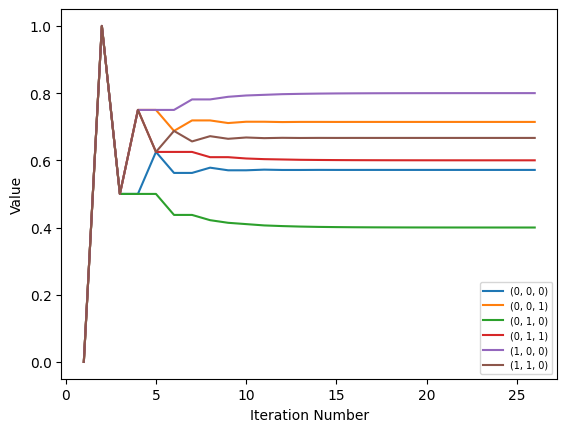

In [13]:
import matplotlib.pyplot as plt

iteration_nums = [i for i in range(1,27,1)]


fig, ax_1 = plt.subplots()

for i in range(0,6):
    ax_1.plot(iteration_nums,val_dict_0[piglet_states[i]],label=str(piglet_states[i]))

plt.xlabel("Iteration Number")
plt.ylabel("Value")
plt.legend(loc="lower right",fontsize="x-small")
plt.show()

## Replication of Figure 3: optimal policy boundary

First we load the Pig policy from the pickle file.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

with open("pig_vi_results.pkl", "rb") as f:
    pig_policy = pickle.load(f)["policy"]

Now we can obtain visualisations for the optimal policy.

In [15]:
T = 100

# 0 is roll and 1 is hold
decision = np.zeros((T, T, T + 1))

for i in range(T):
    for j in range(T):
        for k in range(T + 1):

            # If current score + turn total reaches target,
            # holding wins immediately.
            if i + k >= T:
                decision[i, j, k] = 1

            else:
                if pig_policy[(i, j, k)] == "hold":
                    decision[i, j, k] = 1
                else:
                    decision[i, j, k] = 0

print(decision.shape)

(100, 100, 101)


In [16]:
from skimage import measure # Note skimage requires the scikit-image package

verts, faces, normals, values = measure.marching_cubes(decision, level=0.5)

print("vertices:", verts.shape)
print("faces:", faces.shape)

vertices: (32766, 3)
faces: (64866, 3)


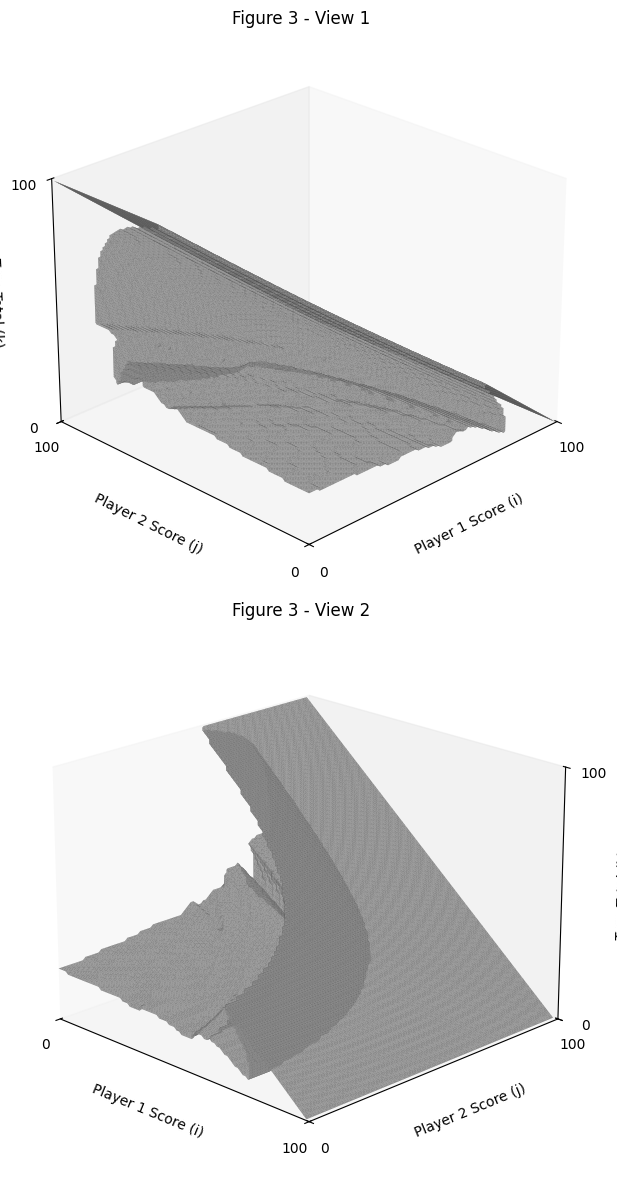

In [17]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

mesh = verts[faces]

fig = plt.figure(figsize=(8, 12))

views = [
    (25, -135, "Figure 3 - View 1"),
    (20,  -45, "Figure 3 - View 2")
]

for n, (elev, azim, title) in enumerate(views, start=1):
    ax = fig.add_subplot(2, 1, n, projection="3d")

    surface = Poly3DCollection(
        mesh,
        facecolor="0.55",
        edgecolor="0.25",
        linewidth=0.03
    )

    ax.add_collection3d(surface)

    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_zlim(0, 100)

    ax.set_xlabel("Player 1 Score (i)")
    ax.set_ylabel("Player 2 Score (j)")
    ax.set_zlabel("Turn Total (k)")

    ax.set_xticks([0, 100])
    ax.set_yticks([0, 100])
    ax.set_zticks([0, 100])

    ax.view_init(elev=elev, azim=azim)
    ax.grid(False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Replication of Figure 4: cross-section for opponent score fixed at 30

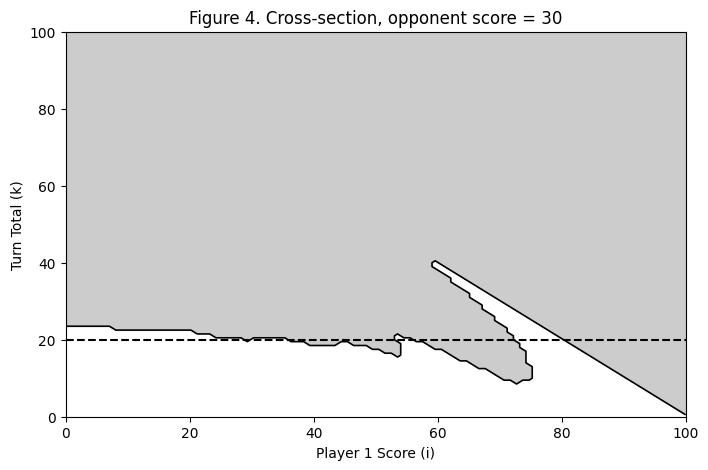

In [19]:
j = 30
Z = decision[:, j, :]

plt.figure(figsize=(8, 5))

plt.contourf(Z.T, levels=[0.5, 1.0], colors=["0.80"], extent=[0, 100, 0, 100])
plt.contour(Z.T, levels=[0.5], colors="black", linewidths=1.2, extent=[0, 100, 0, 100])

plt.axhline(20, linestyle="--", color="black")

plt.xlabel("Player 1 Score (i)")
plt.ylabel("Turn Total (k)")
plt.title("Figure 4. Cross-section, opponent score = 30")

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.show()

## Replication of Figure 5: reachable states

## Replication of Figure 6: reachable states when rolling is optimal

## Replication of Figure 7: win-probability contours

## Key metrics

We give an example of simulating winning probabilities for Pig for different strategies, obtaining our values for 100 replications (note that the values stated in our paper were calculated using 10^6 replications).

In [21]:
from pig_vi.pig_strategies_sim import *

T = 100 # Target score
R = 1000 # Number of replications


strat_hold_20 = strategy_factory_1(20,T)
opt_strat_1 = optimal_strategy_fact()
opt_strat_2 = optimal_strategy_fact()

rep_results_1 = replications(pig_sim, R, T, False, (opt_strat_1,opt_strat_2))
rep_results_2 = replications(pig_sim, R, T, False, (opt_strat_1,strat_hold_20))
rep_results_3 = replications(pig_sim, R, T, False, (strat_hold_20,opt_strat_1))
rep_results_4 = replications(pig_sim, R, T, True, (strat_hold_20,opt_strat_1))
rep_results_1, rep_results_2, rep_results_3, rep_results_4

({'S1 (opt_strat)': 54.5, 'S2 (opt_strat)': 45.5},
 {'S1 (opt_strat)': 58.5, 'S2 (strat_hold_at_20)': 41.5},
 {'S1 (strat_hold_at_20)': 49.5, 'S2 (opt_strat)': 50.5},
 {'S1 (strat_hold_at_20)': 46.8, 'S2 (opt_strat)': 53.2})